TENSORFLOW VERSION

2.20.0

IMPORT LIBRARIES



In [163]:
import os
import pandas as pd
import numpy as np
import zipfile
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras import Input
from tensorflow.keras import Model
import matplotlib.pyplot as plt
from PIL import Image
import json
import random
import pickle
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

LOAD DATASET

In [11]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
for root, dirs, files in os.walk("/content/drive/MyDrive/"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Tumor Classification/APPROVED DATASET/TDD.zip


In [49]:
zip_path = "/content/drive/MyDrive/Tumor Classification/APPROVED DATASET/TDD.zip"
extract_path = "/content/TDD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print ("Dataset extracted successfully")

Dataset extracted successfully


In [50]:
print (os.listdir(extract_path))

['Testing', 'Training']


DATA VISUALISATION

In [58]:
#Count images per class

train_counts = {}
test_counts = {}

for cls in sorted(os.listdir(train_dir)):
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

for cls in sorted(os.listdir(test_dir)):
    test_counts[cls] = len(os.listdir(os.path.join(test_dir, cls)))

print("Training Images")
print(train_counts)

print("\nTesting Images")
print(test_counts)

Training Images
{'glioma_tumor': 826, 'meningioma_tumor': 822, 'no_tumor': 395, 'pituitary_tumor': 827}

Testing Images
{'glioma_tumor': 100, 'meningioma_tumor': 115, 'no_tumor': 105, 'pituitary_tumor': 74}


In [59]:
#summary table

summary = pd.DataFrame({
    "Training Images": train_counts,
    "Testing Images": test_counts
})

summary

,Training Images,Testing Images
glioma_tumor,826,100
meningioma_tumor,822,115
no_tumor,395,105
pituitary_tumor,827,74


In [60]:
#total number of images

print("Total Training Images:", sum(train_counts.values()))
print("Total Testing Images:", sum(test_counts.values()))
print("Total Images:", sum(train_counts.values()) + sum(test_counts.values()))

Total Training Images: 2870
Total Testing Images: 394
Total Images: 3264


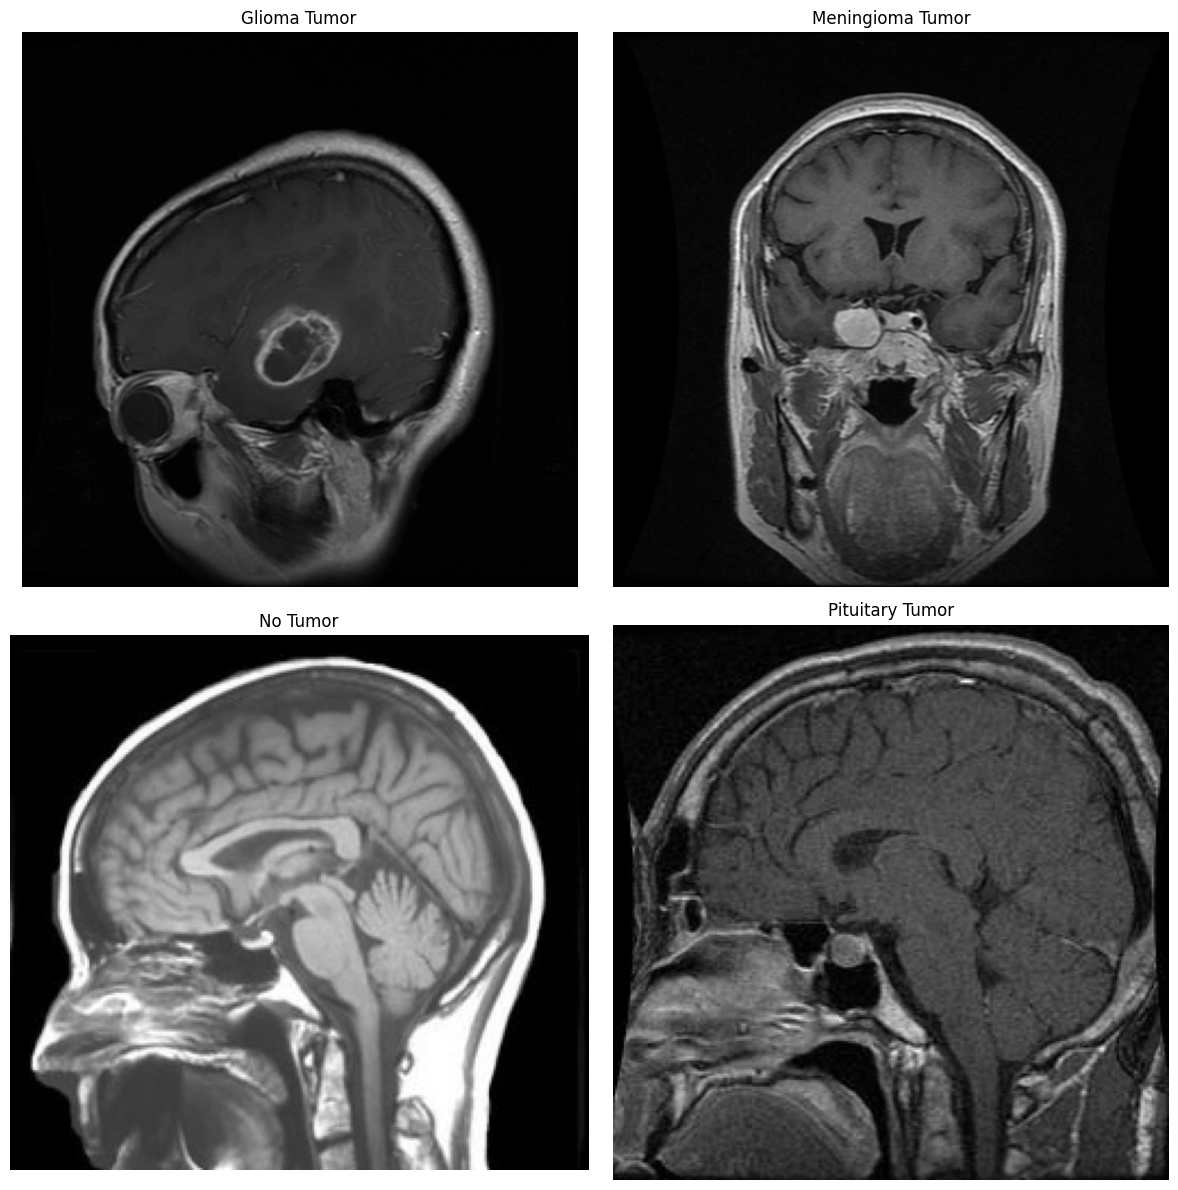

In [65]:
#Visual inspection

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(12, 12))

plot_num = 1

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    image_file = random.choice(os.listdir(class_path))

    img = Image.open(os.path.join(class_path, image_file))

    plt.subplot(2, 2, plot_num)
    plt.imshow(img, cmap="gray")
    plt.title(cls.replace("_", " ").title())
    plt.axis("off")

    plot_num += 1

plt.tight_layout()
plt.show()

DATA CLEANING

In [56]:
#Checking for corrupted images

bad_images = []

for folder in [train_dir, test_dir]:
    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        for img in os.listdir(class_path):
            path = os.path.join(class_path, img)

            try:
                Image.open(path).verify()
            except Exception:
                bad_images.append(path)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


In [61]:
#Checking image sizes

image_sizes = []

for folder in [train_dir, test_dir]:
    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            with Image.open(img_path) as img:
                image_sizes.append(img.size)

sizes_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])

sizes_df.describe()

,Width,Height
count,3264.000000,3264.000000
mean,467.118566,469.780944
std,132.844462,124.756516
min,174.000000,167.000000
25%,512.000000,512.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1375.000000,1446.000000


In [62]:
#Finding unique image sizes

unique_sizes = set(image_sizes)

print(f"Number of unique image sizes: {len(unique_sizes)}")

print("\nSome image sizes:")
print(list(unique_sizes)[:10])

Number of unique image sizes: 440

Some image sizes:
[(491, 624), (206, 244), (409, 442), (503, 369), (430, 483), (728, 725), (201, 251), (289, 354), (383, 407), (554, 554)]


In [63]:
#Check image color mode

image_modes = {}

for folder in [train_dir, test_dir]:
    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            with Image.open(img_path) as img:
                mode = img.mode
                image_modes[mode] = image_modes.get(mode, 0) + 1

print(image_modes)

{'RGB': 3264}


EXPLORATORY DATA ANALYSIS (EDA)

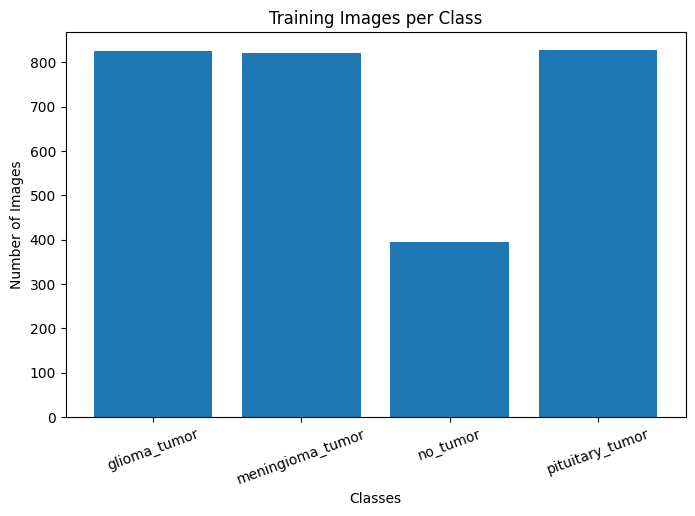

In [66]:
#Plot class distribution

plt.figure(figsize=(8,5))

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

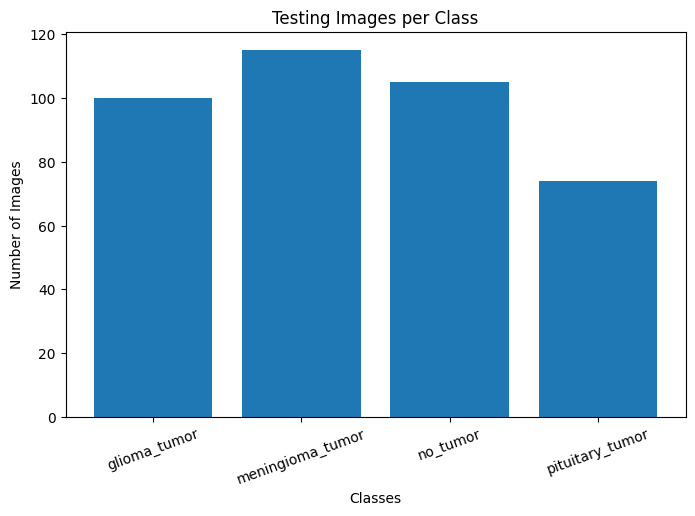

In [67]:
#Plot the testing distribution

plt.figure(figsize=(8,5))

plt.bar(test_counts.keys(), test_counts.values())

plt.title("Testing Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

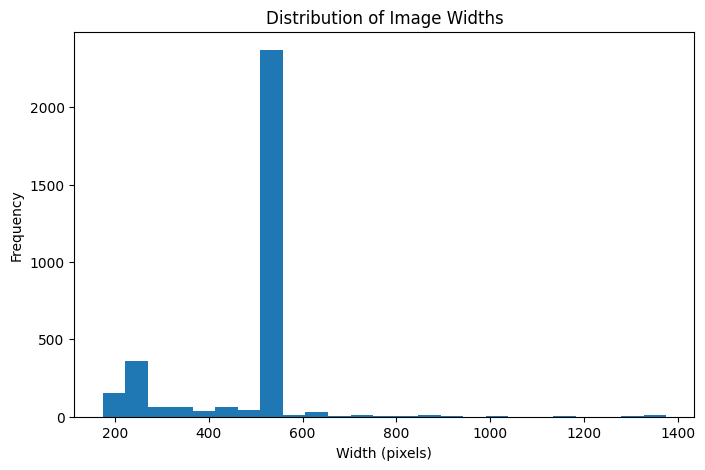

In [68]:
#Plot image width distribution

plt.figure(figsize=(8,5))

plt.hist(sizes_df["Width"], bins=25)

plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.show()

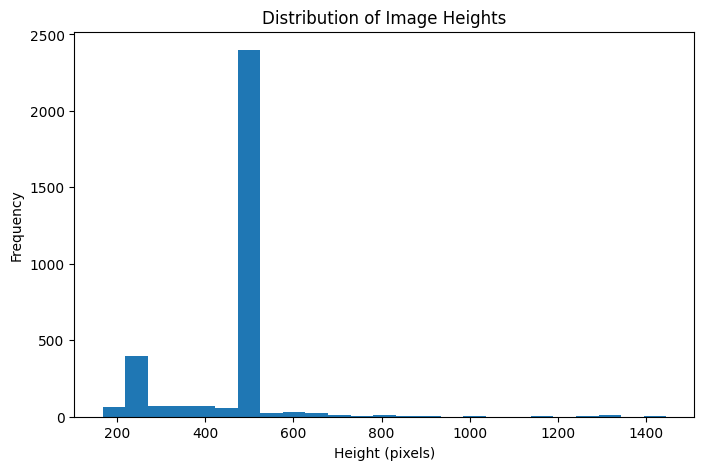

In [69]:
#Plot image height distribution

plt.figure(figsize=(8,5))

plt.hist(sizes_df["Height"], bins=25)

plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.show()

DATA PREPROCESSING

In [95]:
#preprocessing parameters

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [96]:
#Create the training dataset

train_dataset = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.


In [97]:
#Create the validation dataset

validation_dataset = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2870 files belonging to 4 classes.
Using 574 files for validation.


In [98]:
#Create the testing dataset

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names

print(class_names)

Found 394 files belonging to 4 classes.
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


(32, 224, 224, 3)
(32,)


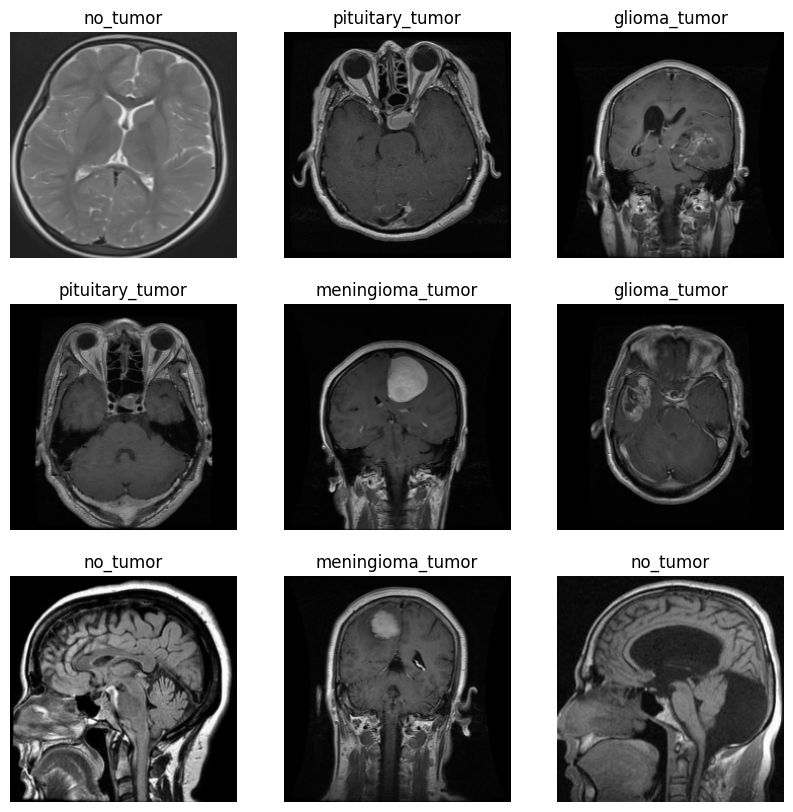

In [99]:
#Inspect one batch

for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

#Display one processed batch

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [100]:
#Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

In [101]:
#Optimize the data pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

In [102]:
#compute class weight

train_labels = np.concatenate(
    [labels.numpy() for images, labels in train_dataset],
    axis=0
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)

{0: np.float64(0.8503703703703703), 1: np.float64(0.8871715610510046), 2: np.float64(1.8050314465408805), 3: np.float64(0.875)}


In [103]:
#verify dataset

for images, labels in train_dataset.take(1):
    print(images.shape)
    print(images.dtype)
    print(tf.reduce_min(images).numpy())
    print(tf.reduce_max(images).numpy())

(32, 224, 224, 3)
<dtype: 'float32'>
0.0
255.0


TRANSFER LEARNING

In [110]:
#Load the pretrained model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [111]:
#Freeze the pretrained layers

base_model.trainable = False

In [117]:
#Build the complete model

inputs = Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# Pass through EfficientNet
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = Model(inputs, outputs)

In [118]:
#Compile the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [119]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [88]:
train_labels = np.concatenate(
    [labels.numpy() for images, labels in train_dataset],
    axis=0
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)

{0: np.float64(0.8503703703703703), 1: np.float64(0.8871715610510046), 2: np.float64(1.8050314465408805), 3: np.float64(0.875)}


In [120]:
#Introducing callbacks


#early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

#save best model
checkpoint = ModelCheckpoint(
    "best_brain_tumor_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [121]:
#Initial training

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5774 - loss: 1.2699
Epoch 1: val_accuracy improved from None to 0.79617, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 174ms/step - accuracy: 0.6659 - loss: 1.0196 - val_accuracy: 0.7962 - val_loss: 0.6366 - learning_rate: 0.0010
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7831 - loss: 0.6364
Epoch 2: val_accuracy did not improve from 0.79617
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.7726 - loss: 0.6410 - val_accuracy: 0.7666 - val_loss: 0.5921 - learning_rate: 0.0010
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7829 - loss: 0.5434
Epoch 3: val_accuracy did not improve from 0.79617
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.7892 - loss: 0.5607 - val_accuracy: 0.7822 - val_loss: 0.5699 - learning_rate: 0.0010
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accura

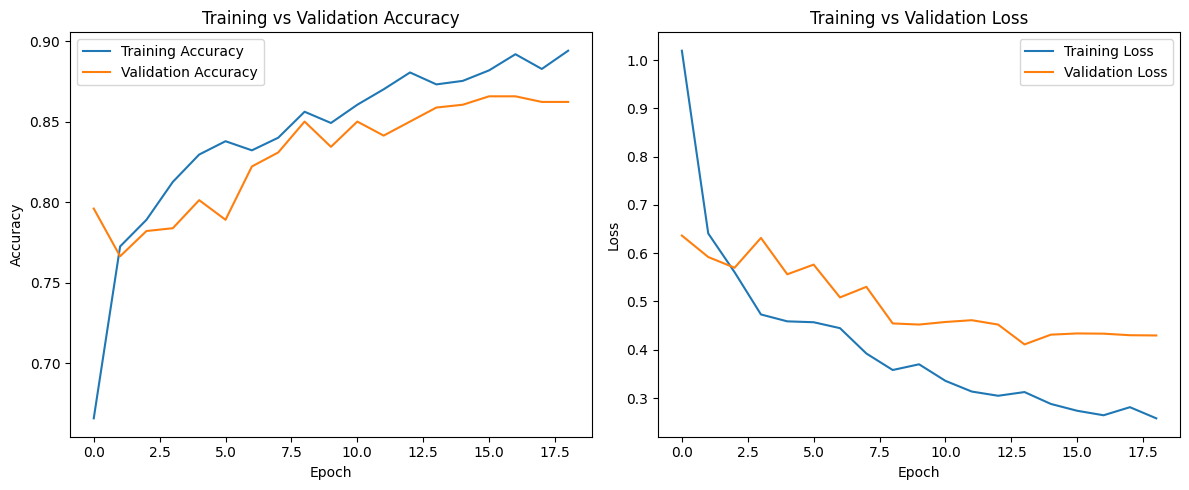

In [157]:
#accuracy and loss plot

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

# Save to Google Drive
plt.savefig("/content/drive/MyDrive/Brain_Tumor_Project/accuracy_loss_plot.png", dpi=300)

plt.show()

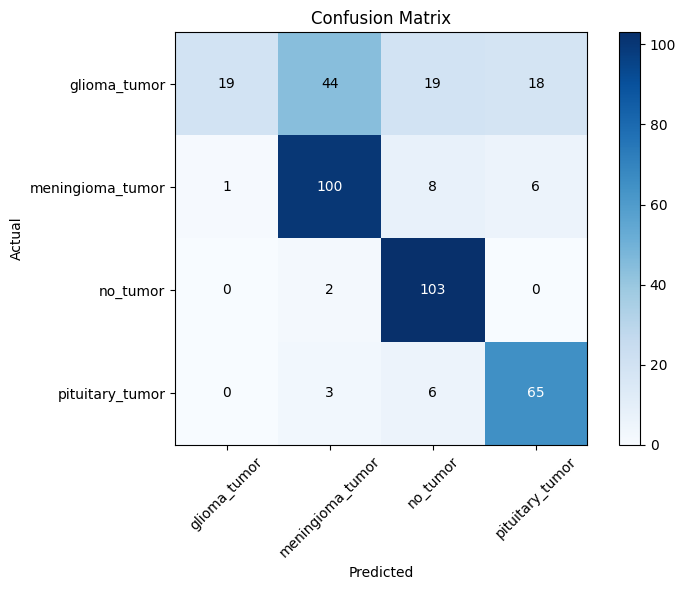

In [158]:
#Confusion matrix

cm = confusion_matrix(true_labels, predicted_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

plt.tight_layout()

# Save it
plt.savefig(
    "/content/drive/MyDrive/Brain_Tumor_Project/confusion_matrix.png",
    dpi=300
)

plt.show()

In [159]:
#Classification report

report = classification_report(
    true_labels,
    predicted_classes,
    target_names=class_names
)

print(report)

with open(
    "/content/drive/MyDrive/Brain_Tumor_Project/classification_report.txt",
    "w"
) as f:
    f.write(report)

                  precision    recall  f1-score   support

    glioma_tumor       0.95      0.19      0.32       100
meningioma_tumor       0.67      0.87      0.76       115
        no_tumor       0.76      0.98      0.85       105
 pituitary_tumor       0.73      0.88      0.80        74

        accuracy                           0.73       394
       macro avg       0.78      0.73      0.68       394
    weighted avg       0.78      0.73      0.68       394



In [161]:
#save training history

with open(
    "/content/drive/MyDrive/Brain_Tumor_Project/training_history.pkl",
    "wb"
) as f:
    pickle.dump(history.history, f)

In [162]:
#save the test predictions

results = pd.DataFrame({
    "Actual": [class_names[i] for i in true_labels],
    "Predicted": [class_names[i] for i in predicted_classes]
})

results.to_csv(
    "/content/drive/MyDrive/Brain_Tumor_Project/test_predictions.csv",
    index=False
)

In [164]:
#save class names

with open("/content/drive/MyDrive/Brain_Tumor_Project/class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("class_names.json saved successfully!")

class_names.json saved successfully!
